In [1]:
import pandas as pd
import psycopg2
import matplotlib.pyplot as plt

In [2]:
caminho_vendas_desafio = "C:\\Users\\PC\\Documents\\ComuniDados_____desafios\\vendas_desafio.csv"
df_vendas_desafio = pd.read_csv(caminho_vendas_desafio,sep=',')
df_vendas_desafio.head()

,id_venda,data_venda,cliente,produto,categoria,quantidade,preco_unitario,vendedor,cidade,estado
0,1,2024-09-27,Pietra,Mouse,Eletrônicos,3,84.74,Ana,Belo Horizonte,RJ
1,2,2024-01-21,Vinicius,Monitor,Eletrônicos,3,950.34,Bruno,São Paulo,RS
2,3,2024-08-02,Yago,Mouse,Eletrônicos,3,79.13,Eduardo,Curitiba,SP
3,4,2024-04-09,Lara,Notebook,Eletrônicos,3,3471.47,Ana,Rio de Janeiro,RJ
4,5,2024-05-29,Levi,Fone,Eletrônicos,4,208.32,Eduardo,São Paulo,RS


In [3]:
df_vendas_desafio['faturamento'] = df_vendas_desafio['quantidade'] * df_vendas_desafio['preco_unitario']
df_vendas_desafio.head(20)


,id_venda,data_venda,cliente,produto,categoria,quantidade,preco_unitario,vendedor,cidade,estado,faturamento
0,1,2024-09-27,Pietra,Mouse,Eletrônicos,3,84.74,Ana,Belo Horizonte,RJ,254.22
1,2,2024-01-21,Vinicius,Monitor,Eletrônicos,3,950.34,Bruno,São Paulo,RS,2851.02
2,3,2024-08-02,Yago,Mouse,Eletrônicos,3,79.13,Eduardo,Curitiba,SP,237.39
3,4,2024-04-09,Lara,Notebook,Eletrônicos,3,3471.47,Ana,Rio de Janeiro,RJ,10414.41
4,5,2024-05-29,Levi,Fone,Eletrônicos,4,208.32,Eduardo,São Paulo,RS,833.28
5,6,2024-10-20,Ravi Lucca,Monitor,Eletrônicos,1,984.58,Eduardo,Curitiba,RJ,984.58
6,7,2024-10-03,Thales,Livro SQL,Livros,2,93.64,Eduardo,Belo Horizonte,SP,187.28
7,8,2024-01-22,José,Teclado,Eletrônicos,1,144.13,Daniela,Belo Horizonte,MG,144.13
8,9,2024-02-18,Isabel,Teclado,Eletrônicos,1,147.96,Bruno,Belo Horizonte,SP,147.96
9,10,2024-06-18,Luan,Mouse,Eletrônicos,3,81.79,Daniela,São Paulo,MG,245.37


In [4]:
faturamento_produto = df_vendas_desafio.groupby('produto')['faturamento'].sum().reset_index()
faturamento_produto.head(20)


,produto,faturamento
0,Cadeira,1629832.30
1,Fone,495633.09
2,Livro Python,296630.22
3,Livro SQL,247460.70
4,Mesa,3092939.21
5,Mochila,460376.91
6,Monitor,2364641.86
7,Mouse,205764.16
8,Notebook,8290852.39
9,Teclado,384771.59


In [5]:
faturamento_categoria = df_vendas_desafio.groupby('categoria')['faturamento'].sum().reset_index()
faturamento_categoria.head(20)

,categoria,faturamento
0,Acessórios,460376.91
1,Eletrônicos,11741663.09
2,Livros,544090.92
3,Móveis,4722771.51


In [6]:
faturamento_cliente = df_vendas_desafio.groupby('cliente')['faturamento'].sum().reset_index()
faturamento_cliente.head(20)

,cliente,faturamento
0,Agatha,72802.44
1,Alana,46255.65
2,Alexandre,65418.73
3,Alexia,56553.65
4,Alice,100859.35
5,Allana,82675.64
6,Alícia,43753.27
7,Amanda,74232.31
8,Ana,42101.68
9,Ana Beatriz,68458.33


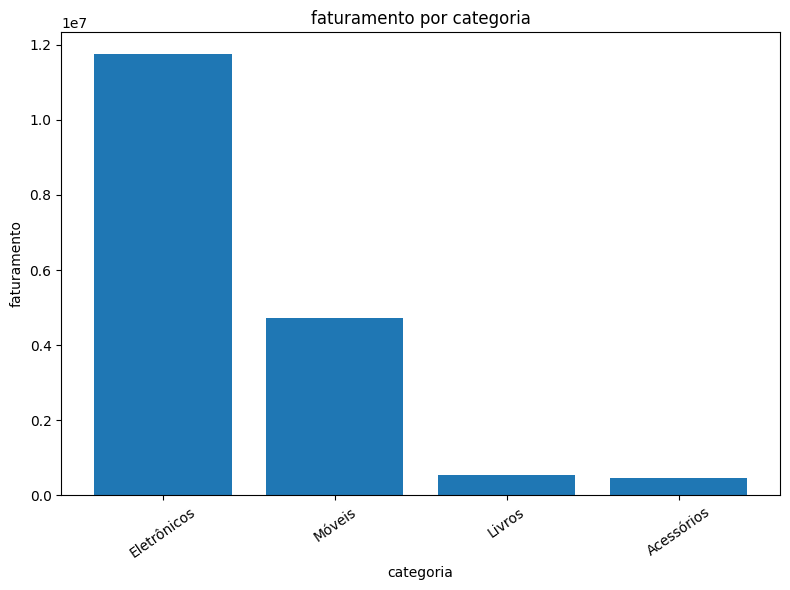

In [7]:
faturamento_categoria = faturamento_categoria.sort_values(by='faturamento', ascending=False)
plt.figure(figsize=(8,6))
plt.bar(faturamento_categoria['categoria'], faturamento_categoria['faturamento'])
plt.title('faturamento por categoria')
plt.xlabel('categoria')
plt.ylabel('faturamento')
plt.xticks(rotation=35)
plt.tight_layout()
plt.show()

In [8]:
faturamento_produto.to_csv('resumo_vendas.csv', index=False)

print("\nArquivo resumo_vendas.csv exportado com sucesso!")


Arquivo resumo_vendas.csv exportado com sucesso!


In [9]:
faturamento_produto.head(20)

,produto,faturamento
0,Cadeira,1629832.30
1,Fone,495633.09
2,Livro Python,296630.22
3,Livro SQL,247460.70
4,Mesa,3092939.21
5,Mochila,460376.91
6,Monitor,2364641.86
7,Mouse,205764.16
8,Notebook,8290852.39
9,Teclado,384771.59
